In [ ]:
%load_ext autoreload
%autoreload 2

# 1. Import CellRefiner and packages

In [5]:
import numpy as np
import squidpy as sq
import seaborn as sns
from matplotlib import pyplot as plt
import scanpy as sc
import cellrefiner as cr

# 2. Load Data

Load Visium spatial transcriptomic data of the mouse kidney via scanpy package

In [6]:
adata_st = sc.datasets.visium_sge(sample_id='V1_Mouse_Kidney')
# preprocess
adata_st.var_names_make_unique()
sc.pp.filter_cells(adata_st,min_genes=3)
sc.pp.filter_genes(adata_st,min_cells=3)
sc.pp.normalize_total(adata_st, inplace=True)
sc.pp.log1p(adata_st)
sc.tl.pca(adata_st, svd_solver='arpack')
sc.pp.neighbors(adata_st, n_neighbors=20, n_pcs=40)
sc.tl.leiden(adata_st, resolution=0.4)

spatial_key = 'spatial'
cluster_key_st = 'leiden'

# remove isolated spots
sq.gr.spatial_neighbors(adata_st)
mean_d = np.zeros(adata_st.shape[0])
indptr = adata_st.obsp['spatial_distances'].indptr
d = adata_st.obsp['spatial_distances'].data
for i in range(adata_st.shape[0]):
    mean_d[i] = d[indptr[i]:indptr[i+1]].mean()
I = ~np.isnan(mean_d)
adata_st = adata_st[I]

print('ST:\n',adata_st)

100%|██████████| 7.62M/7.62M [00:00<00:00, 94.8MB/s]
100%|██████████| 11.4M/11.4M [00:00<00:00, 83.8MB/s]
/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/anndata/_core/anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_313721/2866280654.py:10: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults plea

ST:
 View of AnnData object with n_obs × n_vars = 1431 × 17915
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial', 'log1p', 'pca', 'neighbors', 'leiden', 'spatial_neighbors'
    obsm: 'spatial', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities', 'spatial_connectivities', 'spatial_distances'


/tmp/ipykernel_313721/2866280654.py:21: RuntimeWarning: Mean of empty slice.
  mean_d[i] = d[indptr[i]:indptr[i+1]].mean()
/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


The source data of mouse kidney scRNAseq dataset can be found at the NCBI Gene Expression Omnibus (GEO) under accession GSE117089

Citation: Junyue Cao et al. ,Joint profiling of chromatin accessibility and gene expression in thousands of single cells.Science361,1380-1385(2018).DOI:10.1126/science.aau0730

In [7]:
adata_sc = sc.read_h5ad('../../data_0907/Mouse_Kidney_SC.h5ad')
cluster_key_sc = 'cell_name'
print('SC:\n',adata_sc)

SC:
 AnnData object with n_obs × n_vars = 10727 × 23379
    obs: 'source', 'replicate', 'experiment', 'cell_name', 'n_genes'
    var: 'gene_id', 'gene_type', 'n_cells'
    uns: 'cell_name_colors', 'experiment_colors', 'log1p', 'neighbors', 'pca', 'replicate_colors', 'source_colors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


# 3. Run cellrefiner cell to spot mapping and spatial refinement 

Load the ligand-receptor database sourced from CellChat

In [10]:
db_lr = cr.pp.ligand_receptor_database(species='mouse')
scale = adata_st.uns['spatial']['V1_Mouse_Kidney']['scalefactors']['spot_diameter_fullres']
adata_cr = cr.pp.spatial_mapping(adata_st,adata_sc,db_lr,scale=scale,cluster_key_sc = cluster_key_sc)
print(adata_cr)

/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


GPU acceleration available with CuPy


/home/kxy/miniconda3/envs/cr_39_1/lib/python3.9/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 7155 × 23379
    obs: 'source', 'replicate', 'experiment', 'cell_name', 'n_genes'
    var: 'gene_id', 'gene_type', 'n_cells'
    uns: 'cell_name_colors', 'experiment_colors', 'log1p', 'neighbors', 'pca', 'replicate_colors', 'source_colors', 'umap'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


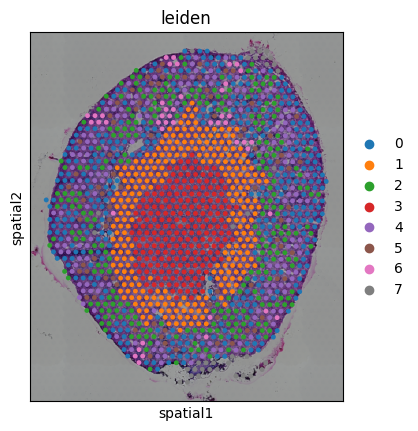

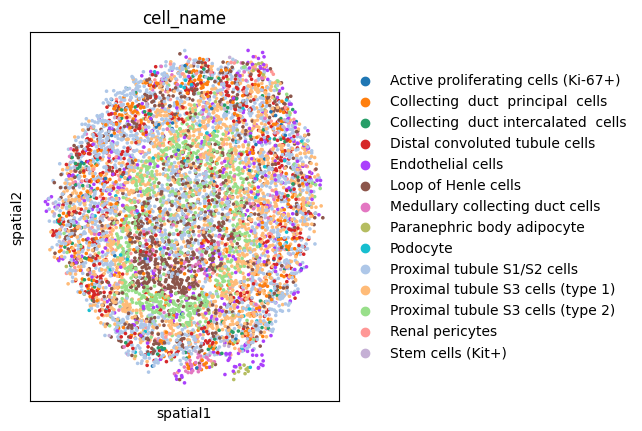

In [11]:
sc.pl.spatial(adata_st, color = cluster_key_st)
sc.pl.spatial(adata_cr, color = cluster_key_sc,spot_size = 70)

# 4. Cell shape modeling

In [12]:
sem = cr.tl.cell_shape_modeling(adata_cr,cluster_key = cluster_key_sc)

Simulation: 100%|██████████| 2000/2000 [06:28<00:00,  5.15it/s]


add .obsp['contacts'], .uns['contacts']
Computing alpha-shape with parameters: alpha=None, ns=10, r=1.2


Processing Cell Shapes: 100%|██████████| 7155/7155 [01:04<00:00, 110.43it/s]


<Axes: >

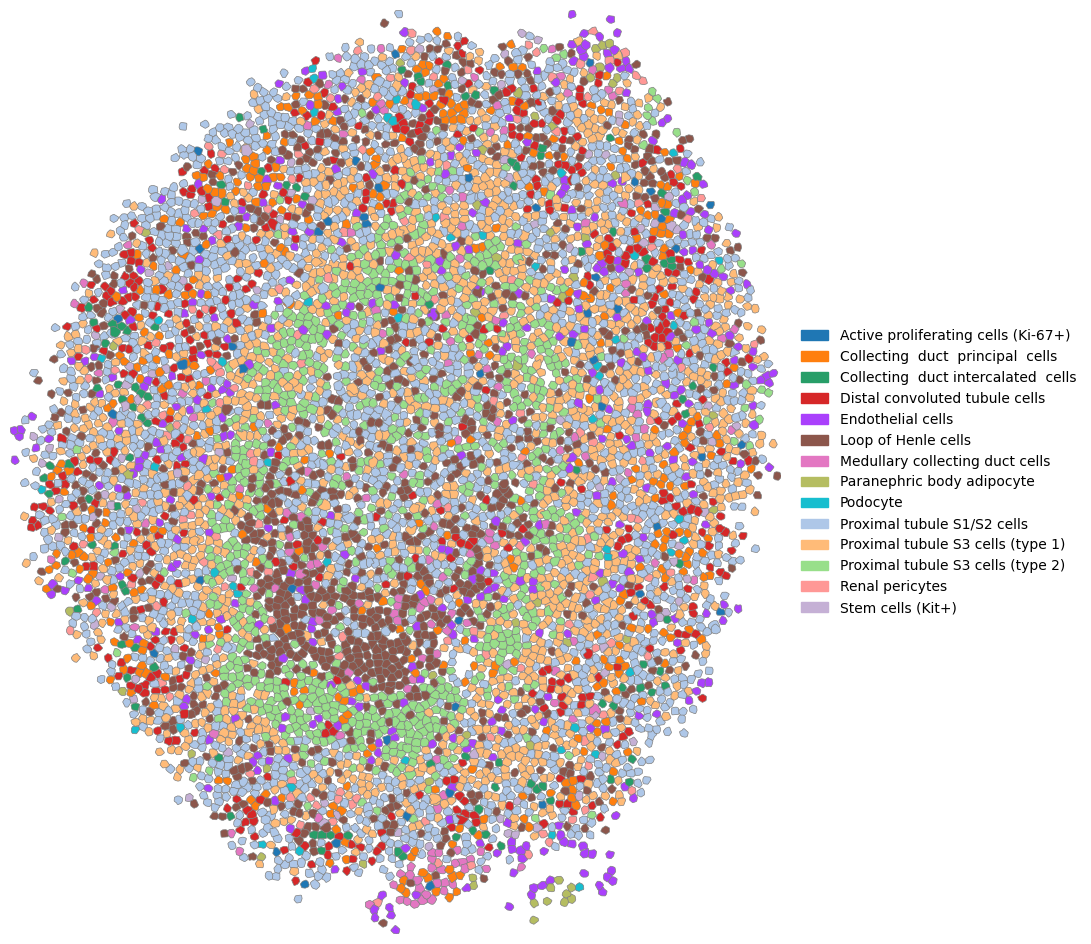

In [13]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5)

# 5. Contact-based communication analysis

In [31]:
db_lr = cr.pp.ligand_receptor_database(signaling_types = 'Cell-Cell Contact')
db_lr = cr.pp.filter_lr_database(db_lr,adata_cr, min_cell_pct=0.01)
cr.tl.contact_communication(db_lr, adata = adata_cr)

add .uns['contact_signal_info']
add .obsm['sender_signal'], .obsm['receiver_signal']


In [ ]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,vis_key='NOTCH',boundary_color='gray',boundary_width=0.1)
cr.pl.plot_contact_signal(sem,ax=ax,signal = 'NOTCH')

Cluster-level communication

In [ ]:
cr.tl.cluster_communication(adata_cr,cluster_key = cluster_key_sc,signal = 'NOTCH')
fig,ax=plt.subplots(figsize=(6,4))
sns.heatmap(adata_cr.uns[f'{cluster_key_sc}-NOTCH']['communication_pvalue']<0.05,square=True,linewidths=1,ax=ax,cmap='Reds',cbar=False)

In [14]:
fig,ax=plt.subplots(figsize=(12,12))
cr.pl.plot_cell_shape(sem,ax=ax,boundary_color='gray',boundary_width=0.5,save_name = 'cell_shape.png')
plt.close(fig)